In [122]:
import pandas as pd
import numpy as np

import os
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/housing.csv.zip
./kaggle/input/housing.csv


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [124]:
df = pd.read_csv("./kaggle/input/housing.csv")

In [125]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [126]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [127]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

In [128]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [129]:
from sklearn.cluster import KMeans
LA_coords = (34.0522, -118.2437)
SF_coords = (37.7749, -122.4194)
df['distance_to_LA'] = np.sqrt((df['latitude'] - LA_coords[0])**2 + (df['longitude'] - LA_coords[1])**2)
df['distance_to_SF'] = np.sqrt((df['latitude'] - SF_coords[0])**2 + (df['longitude'] - SF_coords[1])**2)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']]).astype(str)

df['income_per_room'] = df['median_income'] / df['rooms_per_household']
df['median_income_squared'] = df['median_income'] ** 2

df['is_new_house'] = (df['housing_median_age'] <= 10).astype(int)
df['is_historic_house'] = (df['housing_median_age'] > 30).astype(int)

In [130]:
df.info()
df['ocean_proximity'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  str    
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  distance_to_LA            20640 non-null  float64
 14  distance_to_SF   

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [131]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity','geo_cluster'],
    drop_first=True
)

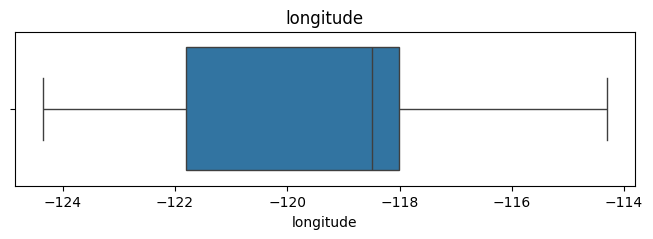

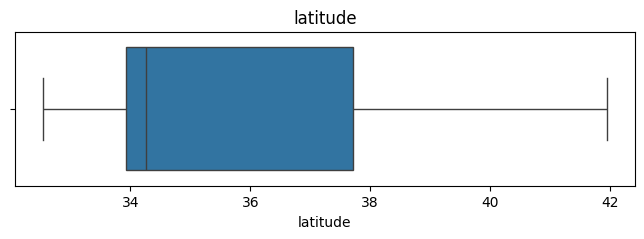

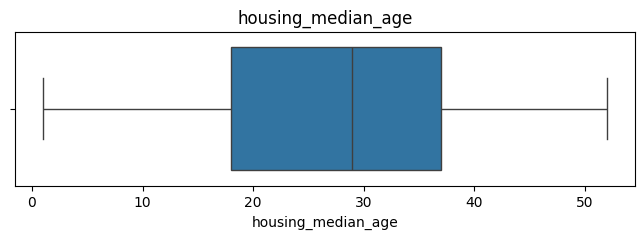

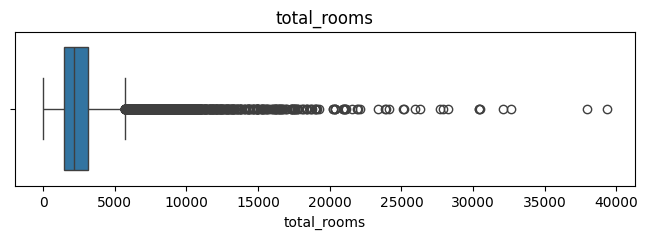

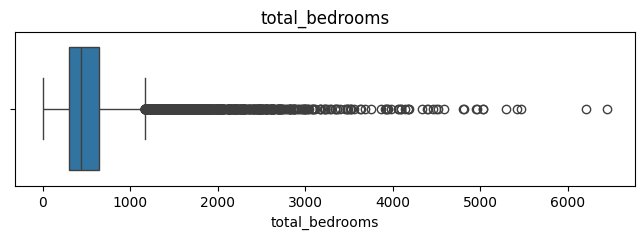

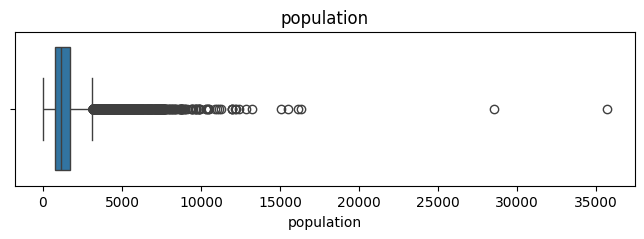

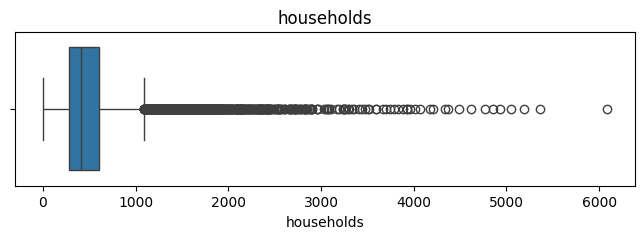

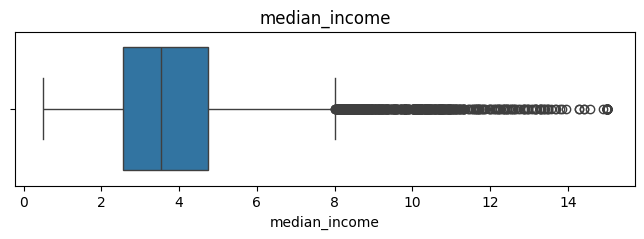

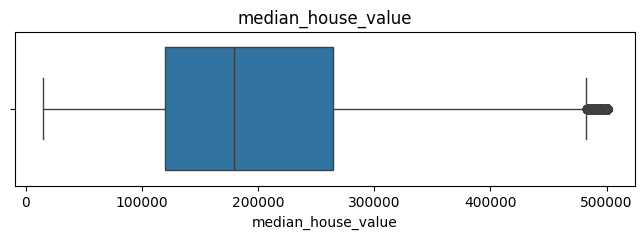

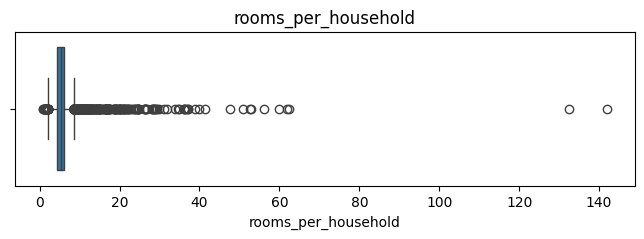

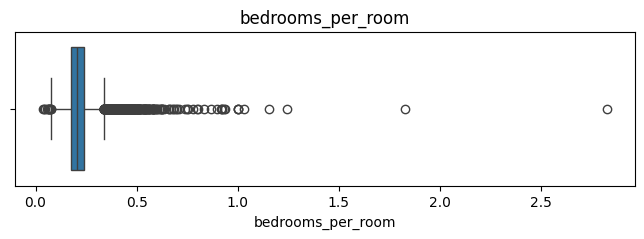

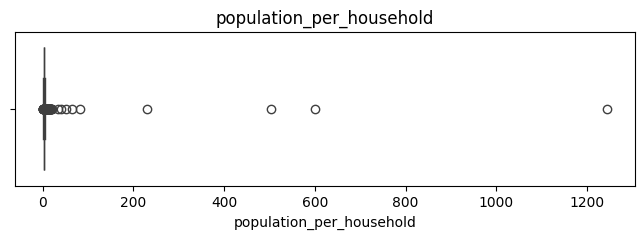

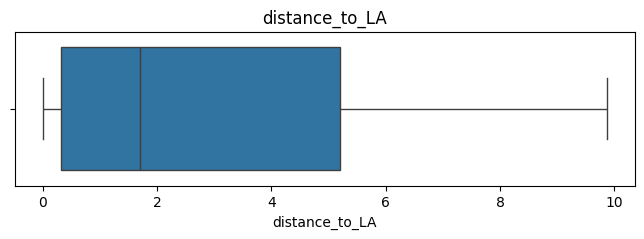

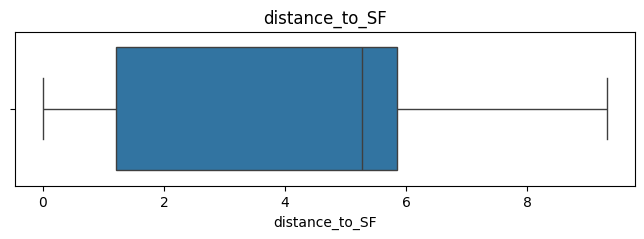

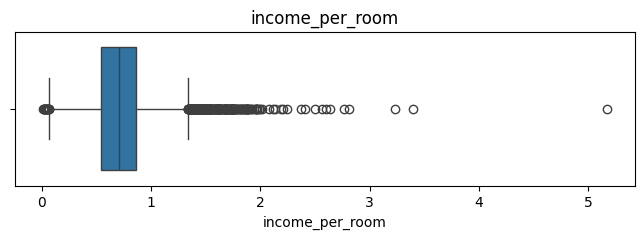

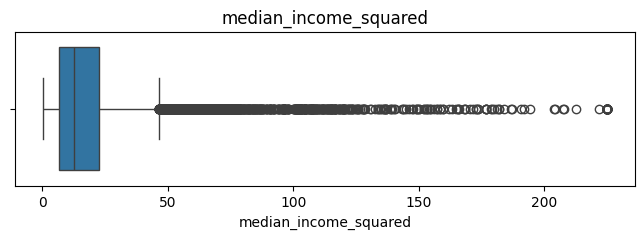

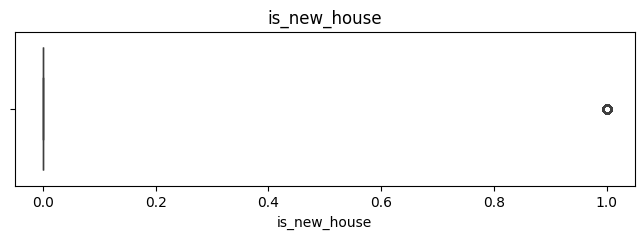

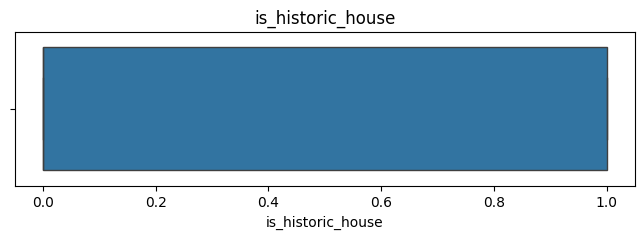

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [133]:

df = df[df['median_house_value'] < 500001]

df = df[df['total_rooms'] < 20000]
df = df[df['population'] < 15000]

df = df[df['rooms_per_household'] < 15]
df = df[df['population_per_household'] < 10]
df = df[df['bedrooms_per_room'] < 0.5]

In [134]:
df.info()

<class 'pandas.DataFrame'>
Index: 19415 entries, 0 to 20639
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   19415 non-null  float64
 1   latitude                    19415 non-null  float64
 2   housing_median_age          19415 non-null  float64
 3   total_rooms                 19415 non-null  float64
 4   total_bedrooms              19415 non-null  float64
 5   population                  19415 non-null  float64
 6   households                  19415 non-null  float64
 7   median_income               19415 non-null  float64
 8   median_house_value          19415 non-null  float64
 9   rooms_per_household         19415 non-null  float64
 10  bedrooms_per_room           19415 non-null  float64
 11  population_per_household    19415 non-null  float64
 12  distance_to_LA              19415 non-null  float64
 13  distance_to_SF              19415 non-null  flo

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'rooms_per_household'}>,
        <Axes: title={'center': 'bedrooms_per_room'}>,
        <Axes: title={'center': 'population_per_household'}>],
       [<Axes: title={'center': 'distance_to_LA'}>,
        <Axes: title={'center': 'distance_to_SF'}>,
        <Axes: title={'center': 'income_per_room'}>,
        <Axes: title={'center': 'median_income_squared'}>],
       [<Axes: title={'center': 'is_new_house'}>,
        <Axes: title={'center': 'is_historic_house'}>, <Axes: >,
        <Axes: >]], dtype=object)

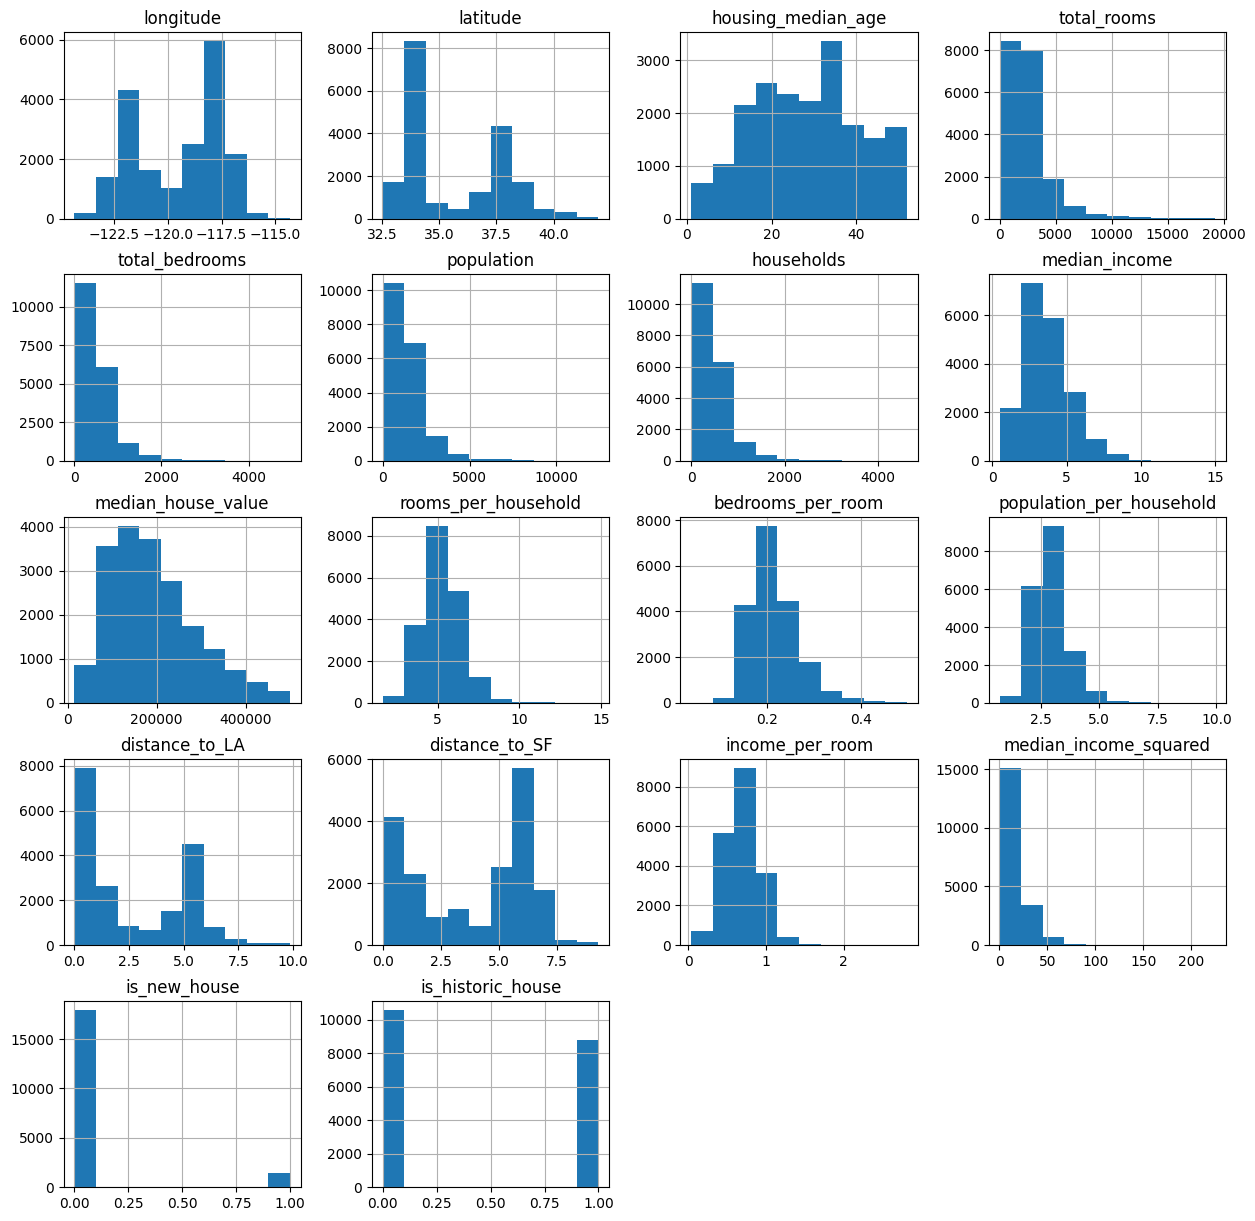

In [135]:
df.head()
df.hist(figsize=(15, 15))

<Axes: >

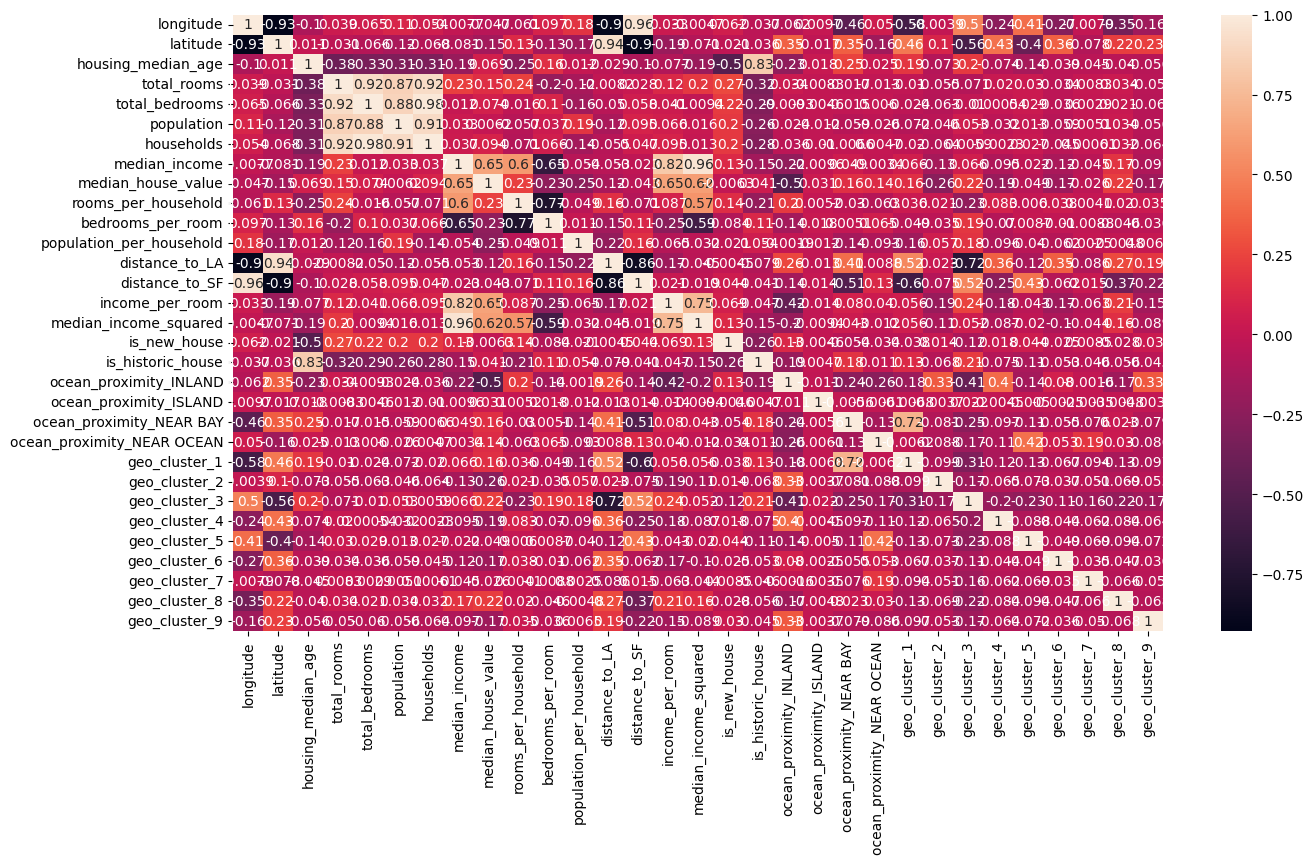

In [136]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True)

In [137]:
X = df.drop(['median_house_value'],axis=1)
y = df['median_house_value']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [138]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [139]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](30,)","[-36493.79,-45571.5 , 12544.8 ,..., -2393.19, 10580. , 1992.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.927e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,30
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](30,)","[288.69,262.38,233.3 ,..., 10.43, 10.18, 7.39]"


In [140]:
y_train_pred = reg.predict(X_train_scaled)
y_test_pred = reg.predict(X_test_scaled)

print(f"Training Score (R2): {r2_score(y_train, y_train_pred):.4f}")
print(f"Testing Score (R2): {r2_score(y_test, y_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

Training Score (R2): 0.6632
Testing Score (R2): 0.6765
RMSE: 55634.23


In [142]:

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

ridge_reg = Ridge(alpha=10.0) 
ridge_reg.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge_reg.predict(X_train_scaled)
y_test_pred_ridge = ridge_reg.predict(X_test_scaled)

print("--- RIDGE REGRESSION ---")
print(f"Training Score (R2): {r2_score(y_train, y_train_pred_ridge):.4f}")
print(f"Testing Score (R2): {r2_score(y_test, y_test_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)):.2f}\n")


lasso_reg = Lasso(alpha=100.0, max_iter=10000)
lasso_reg.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso_reg.predict(X_train_scaled)
y_test_pred_lasso = lasso_reg.predict(X_test_scaled)

print("--- LASSO REGRESSION ---")
print(f"Training Score (R2): {r2_score(y_train, y_train_pred_lasso):.4f}")
print(f"Testing Score (R2): {r2_score(y_test, y_test_pred_lasso):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_lasso)):.2f}\n")


poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)


poly_ridge_reg = Ridge(alpha=100.0)
poly_ridge_reg.fit(X_train_poly, y_train)

y_train_pred_poly = poly_ridge_reg.predict(X_train_poly)
y_test_pred_poly = poly_ridge_reg.predict(X_test_poly)

print("--- POLYNOMIAL + RIDGE REGRESSION ---")
print(f"Training Score (R2): {r2_score(y_train, y_train_pred_poly):.4f}")
print(f"Testing Score (R2): {r2_score(y_test, y_test_pred_poly):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poly)):.2f}")

--- RIDGE REGRESSION ---
Training Score (R2): 0.6632
Testing Score (R2): 0.6766
RMSE: 55628.37

--- LASSO REGRESSION ---
Training Score (R2): 0.6625
Testing Score (R2): 0.6760
RMSE: 55676.86

--- POLYNOMIAL + RIDGE REGRESSION ---
Training Score (R2): 0.7535
Testing Score (R2): 0.7412
RMSE: 49763.27


In [143]:
import pandas as pd

results_df = pd.DataFrame({
    'Gia_Thuc_Te': y_test,
    'Du_Doan_Lasso': y_test_pred_lasso,
    'Du_Doan_Poly_Ridge': y_test_pred_poly
})

results_df['Chenh_Lech_Lasso'] = results_df['Du_Doan_Lasso'] - results_df['Gia_Thuc_Te']

results_df.to_csv('ket_qua_du_doan_gia_nha.csv', index=False)

print("Đã xuất file kết quả: ket_qua_du_doan_gia_nha.csv")

Đã xuất file kết quả: ket_qua_du_doan_gia_nha.csv
